In [1]:
using LinearAlgebra, CairoMakie, LaTeXStrings

# Ising Ring-Ancilla Level Statistics

In [3]:
@inline function translate_bits(state::Int, N::Int)
    return (state >> 1) | ((state & 1) << (N - 1))
end

"""
Finds the 'cycle rep' (minimum integer value under translation) 
and the period (number of shifts to return to the original state).
"""
function get_rep_and_period(chain_state::Int, N::Int)
    rep = chain_state
    shift_state = chain_state
    period = N
    
    for i in 1:(N-1)
        shift_state = translate_bits(shift_state, N)
        if shift_state < rep
            rep = shift_state
        end
        if shift_state == chain_state && period == N
            period = i
        end
    end
    return rep, period
end

function build_k0_hamiltonian(N::Int, J::Float64, λ::Float64, h::Float64, hA::Float64, g::Float64, gA::Float64)
    basis = Dict{Int, Int}() 
    periods = Int[]
    
    idx = 1
    for ancilla in 0:1
        for chain in 0:((1<<N)-1)
            rep, period = get_rep_and_period(chain, N)
            if rep == chain # This state is a valid cycle rep
                full_state = rep | (ancilla << N)
                basis[full_state] = idx
                push!(periods, period)
                idx += 1
            end
        end
    end
    
    dim = length(periods)
   # println("Reduced Hilbert Space Dimension for k=0: ", dim)
    
    H = zeros(Float64, dim, dim)
    
    for (state, i) in basis
        ancilla = state >> N
        chain = state & ((1<<N)-1)
        Ra = periods[i]
        
        diag_val = 0.0
        
        # Ancilla Z
        sz_ancilla = ancilla == 1 ? -0.5 : 0.5
        diag_val -= gA * sz_ancilla
        
        # Ancilla X (Off-diagonal)
        new_ancilla = 1 - ancilla
        new_state = chain | (new_ancilla << N)
        j = basis[new_state]
        Rb = periods[j]
        H[i, j] -= hA * 0.5 * sqrt(Rb / Ra)
        
        # Chain ZZ
        for site in 1:(N-1)
            sz_j   = ((chain >> (site-1)) & 1) == 1 ? -0.5 : 0.5
            sz_jp1 = ((chain >> site) & 1) == 1 ? -0.5 : 0.5
            diag_val += J * sz_j * sz_jp1
        end
        # Periodic boundary ZZ
        sz_N = ((chain >> (N-1)) & 1) == 1 ? -0.5 : 0.5
        sz_1 = (chain & 1) == 1 ? -0.5 : 0.5
        diag_val += J * sz_N * sz_1
        
        # Chain Z, Lambda, and X
        for site in 1:N
            sz_j = ((chain >> (site-1)) & 1) == 1 ? -0.5 : 0.5
            diag_val += λ * sz_j * sz_ancilla - g * sz_j
            
            # Chain X (Off-diagonal)
            flipped_chain = chain ⊻ (1 << (site-1))
            rep_b, Rb_chain = get_rep_and_period(flipped_chain, N)
            new_state_b = rep_b | (ancilla << N)
            j_b = basis[new_state_b]
            
            # The matrix element scaling factor for momentum states
            H[i, j_b] -= h * 0.5 * sqrt(Rb_chain / Ra)
        end
        
        H[i, i] += diag_val
    end
    
    return Symmetric(H)
end

function compute_gap_ratio(evals::Vector{Float64}; trim_fraction=0.33)
    dim = length(evals)
    
    start_idx = floor(Int, dim * trim_fraction) + 1
    end_idx = floor(Int, dim * (1.0 - trim_fraction))
    bulk_evals = evals[start_idx:end_idx]
    
    spacings = diff(bulk_evals)
    r_sum = 0.0
    
    for i in 1:(length(spacings)-1)
        s1 = spacings[i]
        s2 = spacings[i+1]
        r_sum += min(s1, s2) / max(s1, s2)
    end
    
    return r_sum / (length(spacings) - 1)
end

# A chaotic (Wigner-Dyson GOE) system yields r ≈ 0.5307
# An integrable/localized (Poisson) system yields r ≈ 0.386

compute_gap_ratio (generic function with 1 method)

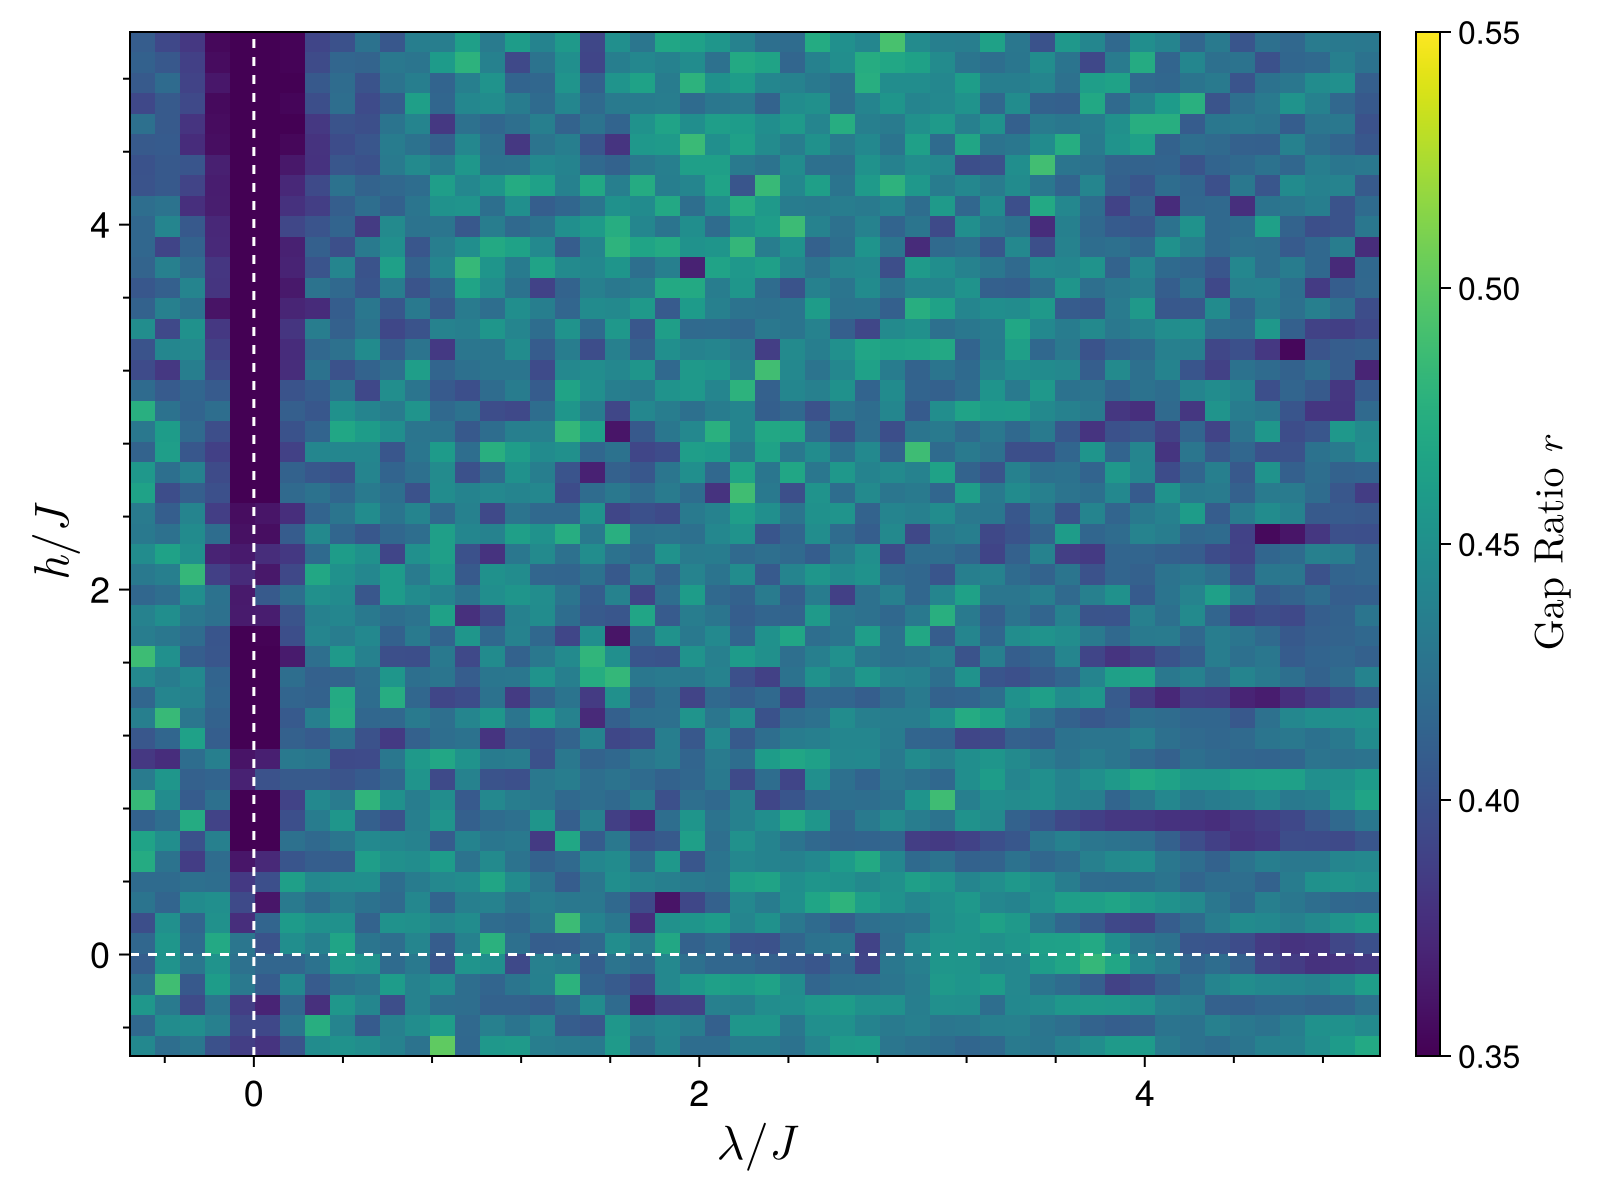

CairoMakie.Screen{IMAGE}


In [4]:
# Fixed J = 1, g = 0; vary λ,h
fig = Figure(size = (800, 600))
xmin = nothing; xmax = nothing; 
ymin = nothing; ymax = nothing;

ax_g = Axis(fig[1,1], 
    xlabel = L"\lambda/J", xlabelsize = 24, 
    ylabel = L"h/J", ylabelsize = 24,
    xgridvisible = false, xminorgridvisible = false, xminorticks = IntervalsBetween(5), xminorticksvisible = true,
    ygridvisible = false, yminorgridvisible = false, yminorticks = IntervalsBetween(5), yminorticksvisible = true, 
    xticklabelsize = 18, #xticks = [0,25,50,75,100],
    yticklabelsize = 18, #yticks = [-0.25,0,0.25], 
    limits = (xmin, xmax, ymin, ymax)
)

N = 12;
J = 1.;
g = gA = 0.;

lpts = 50; hpts = 50;
larr = range(-0.5,5,lpts);
harr = range(-0.5,5,hpts);
r_arr = zeros(hpts, lpts);

for (i,l) in enumerate(larr)
    for (j,h) in enumerate(harr)
        λ = l;
        hA = h
        
        H_k0 = build_k0_hamiltonian(N, J, λ, h, hA, g, gA)
        evals = eigvals!(H_k0);
        r_arr[j,i] = compute_gap_ratio(evals);
    end
end

hm = heatmap!(ax_g, larr, harr, r_arr, colorrange = (0.35, 0.55))
vlines!(ax_g, [0], color = :white, linestyle = :dash)
hlines!(ax_g, [0], color = :white, linestyle = :dash)
Colorbar(fig[1, 2], hm, label = L"Gap Ratio $r$", labelsize = 20, ticklabelsize = 16)

display(fig)

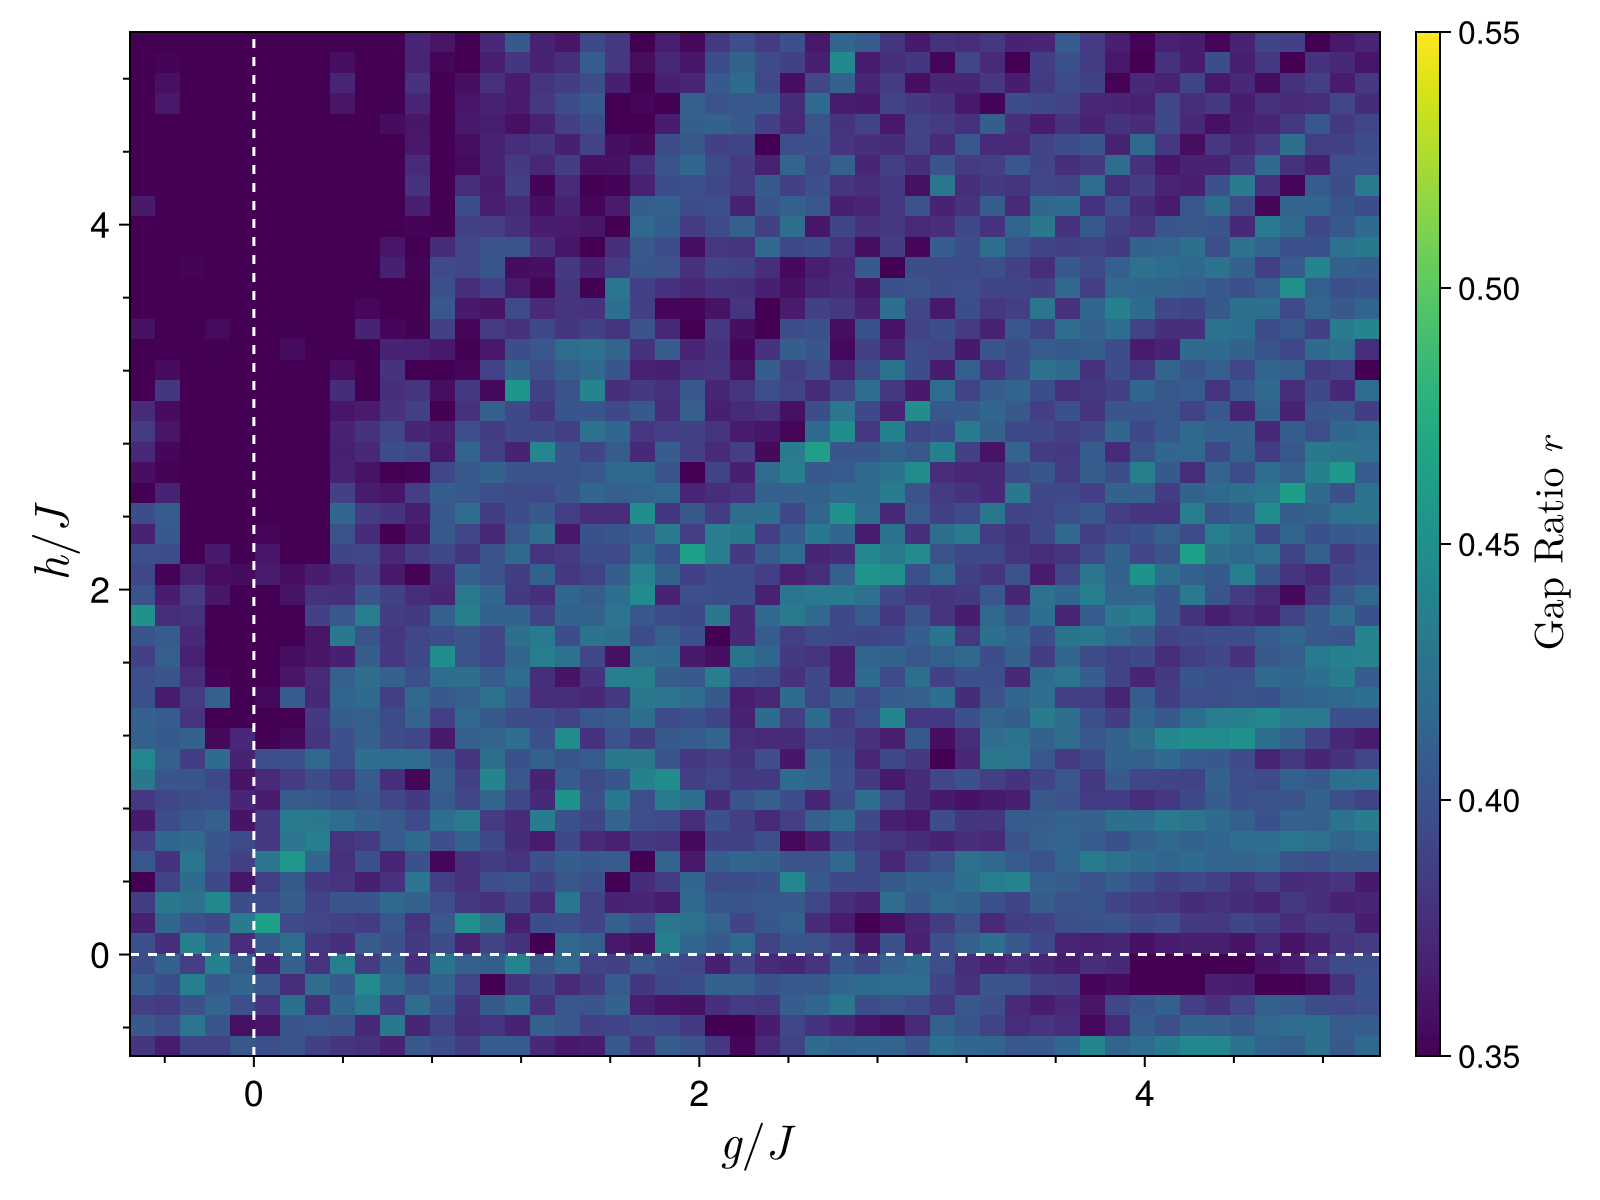

CairoMakie.Screen{IMAGE}


In [5]:
# Fixed J = 1, λ = 0; vary h,g
fig = Figure(size = (800, 600))
xmin = nothing; xmax = nothing; 
ymin = nothing; ymax = nothing;

ax_l = Axis(fig[1,1], 
    xlabel = L"g/J", xlabelsize = 24, 
    ylabel = L"h/J", ylabelsize = 24,
    xgridvisible = false, xminorgridvisible = false, xminorticks = IntervalsBetween(5), xminorticksvisible = true,
    ygridvisible = false, yminorgridvisible = false, yminorticks = IntervalsBetween(5), yminorticksvisible = true, 
    xticklabelsize = 18, #xticks = [0,25,50,75,100],
    yticklabelsize = 18, #yticks = [-0.25,0,0.25], 
    limits = (xmin, xmax, ymin, ymax)
)

N = 12;
J = 1.;
λ = 0.;
g = gA = 0.;

hpts = 50; gpts = 50; 
harr = range(-0.5,5,hpts);
garr = range(-0.5,5,gpts);
r_arr = zeros(hpts, gpts);

for (i,g) in enumerate(garr)
    for (j,h) in enumerate(harr)
        gA= g;
        hA = h
        
        H_k0 = build_k0_hamiltonian(N, J, λ, h, hA, g, gA)
        evals = eigvals!(H_k0);
        r_arr[j,i] = compute_gap_ratio(evals);
    end
end

hm = heatmap!(ax_l, garr, harr, r_arr, colorrange = (0.35, 0.55))
vlines!(ax_l, [0], color = :white, linestyle = :dash)
hlines!(ax_l, [0], color = :white, linestyle = :dash)

Colorbar(fig[1, 2], hm, label = L"Gap Ratio $r$", labelsize = 20, ticklabelsize = 16)

display(fig)

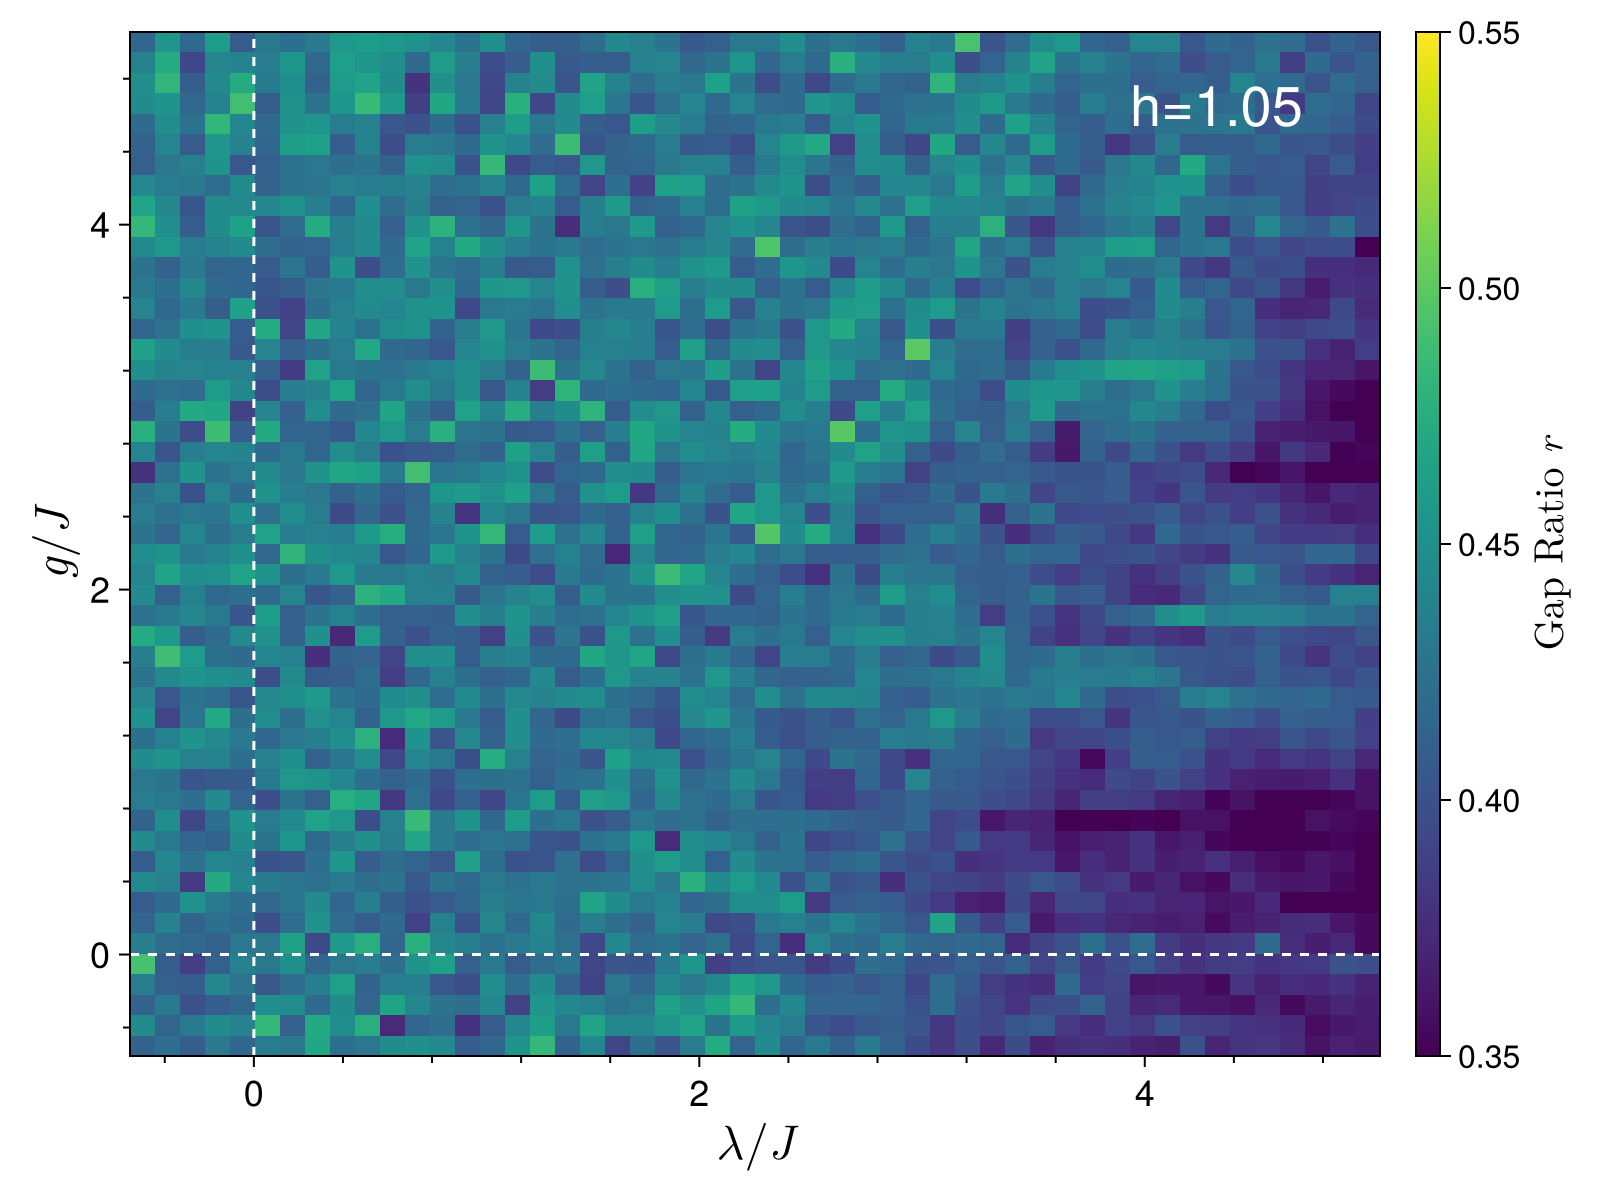

CairoMakie.Screen{IMAGE}


In [6]:
# fixed J = 1, h = 0; vary λ,g
fig = Figure(size = (800, 600))
xmin = nothing; xmax = nothing; 
ymin = nothing; ymax = nothing;

ax_h = Axis(fig[1,1], 
    xlabel = L"\lambda/J", xlabelsize = 24, 
    ylabel = L"g/J", ylabelsize = 24,
    xgridvisible = false, xminorgridvisible = false, xminorticks = IntervalsBetween(5), xminorticksvisible = true,
    ygridvisible = false, yminorgridvisible = false, yminorticks = IntervalsBetween(5), yminorticksvisible = true, 
    xticklabelsize = 18, #xticks = [0,25,50,75,100],
    yticklabelsize = 18, #yticks = [-0.25,0,0.25], 
    limits = (xmin, xmax, ymin, ymax)
)

N = 12;
J = 1.;
h = hA = 1.05;

lpts = 50; gpts = 50; 
larr = range(-0.5,5,hpts);
garr = range(-0.5,5,gpts);
r_arr = zeros(hpts, gpts);

for (i,g) in enumerate(garr)
    for (j,l) in enumerate(larr)
        gA = g;
        λ = l
        
        H_k0 = build_k0_hamiltonian(N, J, λ, h, hA, g, gA)
        evals = eigvals!(H_k0);
        r_arr[i,j] = compute_gap_ratio(evals);
    end
end

hm = heatmap!(ax_h, larr, garr, r_arr, colorrange = (0.35, 0.55))
vlines!(ax_h, [0], color = :white, linestyle = :dash)
hlines!(ax_h, [0], color = :white, linestyle = :dash)
text!(ax_h, 0.8, 0.96, 
    text = "h=$(h)", fontsize = 28, color = :white,
    space = :relative, align = (:left, :top))

Colorbar(fig[1, 2], hm, label = L"Gap Ratio $r$", labelsize = 20, ticklabelsize = 16)       

display(fig)